Naive Bayes Analysis
==============================================================
Research Questions addressed:



Install libraries (as needed)

In [27]:
# %pip install scikit-learn # <- uncomment to install scikit-learn if needed

Import libraries

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f'{x:,.4f}')


Load dataset

In [29]:
ht_risk_df = pd.read_csv('../data/nhanes_hypertension_risk.csv')
ht_risk_df

,participant_id,age,race_ethnicity,education,poverty_income_ratio,marital_status,diagnosed_high_bp,diagnosed_twice,on_chol_medication,bmi,waist_cm,weight_kg,height_cm,smoked_100_cigarettes,smoke_frequency,avg_drinks_per_day,time_sitting,total_cholesterol_mgdl,HDL_cholesterol_mgdl,fasting_glucose_mgdl,LDL_cholesterol_mgdl_friedewald,LDL_cholesterol_mgdl_martin,LDL_cholesterol_mgdl_nih,systolic_avg,systolic_clinical,diastolic_avg,diastolic_clinical,pulse_avg,pulse_clinical,hypertension_risk,male,ever_smoker,current_smoker,drinks_alcohol,drink_frequency_past_year,high_cholesterol,moderate_minutes_per_week,vigorous_minutes_per_week,physically_active
0,130378,43.0000,Non-Hispanic Asian,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,27.0000,98.3000,86.9000,179.5000,1.0000,3.0000,1.3333,360.0000,264.0000,45.0000,113.0000,188.0000,190.0000,191.0000,132.6667,131.5000,96.0000,95.0000,81.0000,80.5000,1,1,1,0,1,208.0000,0,135.0000,135.0000,1
1,130379,66.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,33.5000,114.7000,101.8000,174.2000,1.0000,3.0000,3.0000,480.0000,214.0000,60.0000,125.3333,137.0000,135.0000,139.0000,117.0000,115.0000,78.6667,76.0000,72.0000,72.0000,1,1,1,0,1,300.0000,0,180.0000,135.0000,1
2,130380,44.0000,Other Hispanic,HS/GED or equivalent,1.4100,Married/Living with Partner,0,0.0000,Yes,29.7000,93.5000,69.4000,152.9000,2.0000,3.0000,1.0000,240.0000,187.0000,49.0000,156.0000,63.0000,90.0000,78.0000,109.0000,108.0000,78.3333,78.0000,81.3333,80.0000,1,0,0,0,1,1.0000,1,20.0000,21.9045,0
3,130386,34.0000,Mexican American,Some college or AA degree,1.3300,Married/Living with Partner,0,0.0000,No,30.2000,106.1000,90.6000,173.3000,1.0000,3.0000,2.0000,180.0000,183.0000,46.0000,100.0000,109.0000,111.0000,112.0000,115.0000,117.5000,73.6667,74.5000,62.3333,64.0000,0,1,1,0,1,104.0000,0,30.0000,6.9045,0
4,130394,51.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,0,0.0000,No,24.4000,92.1000,76.7000,177.3000,2.0000,3.0000,1.0000,420.0000,183.0000,48.0000,88.0000,124.0000,120.0000,124.0000,110.6667,116.5000,68.0000,67.5000,79.6667,80.5000,0,1,0,0,1,24.0000,0,0.0000,120.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,142301,80.0000,Non-Hispanic White,College graduate or above,1.2000,Widowed/Divorced/Separated,1,1.0000,No,30.5000,79.7000,82.2000,164.3000,1.0000,3.0000,2.0000,360.0000,138.0000,48.0000,110.0000,61.0000,67.0000,65.0000,140.4444,112.1667,75.3333,72.8333,69.7778,79.0000,1,0,1,0,1,1.0000,1,76.4020,21.9045,0
3558,142303,69.0000,Non-Hispanic White,HS/GED or equivalent,0.9800,Widowed/Divorced/Separated,0,0.0000,Yes,27.9000,111.0000,70.8000,159.2000,1.0000,3.0000,0.0000,360.0000,110.0000,34.0000,160.0000,45.0000,53.0000,50.0000,127.0000,126.0000,69.3333,68.5000,75.3333,75.0000,1,0,1,0,0,0.0000,0,840.0000,95.0000,1
3559,142305,76.0000,Mexican American,<HS,2.2500,Widowed/Divorced/Separated,1,1.0000,Yes,26.4000,89.0000,60.4000,151.4000,2.0000,3.0000,1.3333,480.0000,180.0000,51.0000,132.0000,92.0000,101.0000,97.0000,143.6667,146.0000,79.3333,78.5000,70.6667,70.5000,1,0,0,0,1,17.3333,1,80.0000,21.9045,0
3560,142308,50.0000,Other Hispanic,Some college or AA degree,1.9500,Married/Living with Partner,0,0.0000,No,26.4000,98.4000,79.3000,173.3000,2.0000,3.0000,2.0000,600.0000,166.0000,42.6667,112.6667,61.3333,122.6667,88.6667,108.0000,109.0000,69.3333,71.5000,62.6667,65.0000,0,1,0,0,1,8.0000,0,45.0000,24.6030,0


Configuration Settings

In [30]:
output_dir  = "../visualizations/models"
seed = 42
palette = "Set2"

# define feature columns 
feature_cols = ht_risk_df.copy()
print(feature_cols)
print(len(feature_cols), 'input features')

# define output feature (target)
y =  ht_risk_df['hypertension_risk']
print('distribution of target value:\n', y.value_counts())

      participant_id     age      race_ethnicity                  education  poverty_income_ratio               marital_status  diagnosed_high_bp  diagnosed_twice on_chol_medication     bmi  waist_cm  weight_kg  height_cm  smoked_100_cigarettes  smoke_frequency  avg_drinks_per_day  time_sitting  total_cholesterol_mgdl  HDL_cholesterol_mgdl  fasting_glucose_mgdl  LDL_cholesterol_mgdl_friedewald  LDL_cholesterol_mgdl_martin  LDL_cholesterol_mgdl_nih  systolic_avg  systolic_clinical  diastolic_avg  diastolic_clinical  pulse_avg  pulse_clinical  hypertension_risk  male  ever_smoker  current_smoker  drinks_alcohol  drink_frequency_past_year  high_cholesterol  moderate_minutes_per_week  vigorous_minutes_per_week  physically_active
0             130378 43.0000  Non-Hispanic Asian  College graduate or above                5.0000  Married/Living with Partner                  1           1.0000                 No 27.0000   98.3000    86.9000   179.5000                 1.0000           3.0000    

---

Additional Transformations Needed for Naive Bayes

In [ ]:
# feature engineering
cat_features = ["race_ethnicity", "male", "marital_status", "education",
                 "current_smoker", "ever_smoker", "drinks_alcohol", "physically_active",
                 "high_cholesterol"]
 
continuous_to_bin = {
    "age": [0, 30, 40, 50, 60, 70, 120],
    "time_sitting": [-1, 240, 480, 720, 5000],
    "total_cholesterol_mgdl": [-1, 200, 240, 1000],   # normal / borderline / high
    "avg_drinks_per_day": [-1, 0.01, 1, 2, 100],        # none / light / moderate / heavy
    "poverty_income_ratio": [-1, 1.3, 2.5, 4, 100],     # roughly poverty / low / mid / high
}
 
X = pd.DataFrame(index=feature_cols.index)
 
for col, bins in continuous_to_bin.items():
    labels = list(range(len(bins) - 1))
    X[col + "_bin"] = pd.cut(feature_cols[col], bins=bins, labels=labels).astype(int)
 
for col in cat_features:
    X[col] = feature_cols[col].astype(str)
 
# once hot encode nominal catgories, pass-though bins
nominal_cols = ["race_ethnicity", "male", "marital_status", "education",
                 "current_smoker", "ever_smoker", "drinks_alcohol", "physically_active",
                 "high_cholesterol"]
bin_cols = [c for c in X.columns if c.endswith("_bin")]
 
all_cat_cols = nominal_cols + bin_cols  # one-hot EVERYTHING: each bin level becomes its own category so MNB can learn a separate effect per level,
                                        # instead of assuming the effect scales linearly with the bin number
preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), all_cat_cols),
])
 
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", MultinomialNB()),
])
 
# split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

Naive Bayes Analysis

MODEL PERFORMANCE
              precision    recall  f1-score   support

    low risk       0.70      0.65      0.68       284
   high risk       0.78      0.81      0.80       429

    accuracy                           0.75       713
   macro avg       0.74      0.73      0.74       713
weighted avg       0.75      0.75      0.75       713

ROC AUC: 0.823


Text(0.5, 1.0, 'Confusion Matrix for Naive Bayes Classifier')

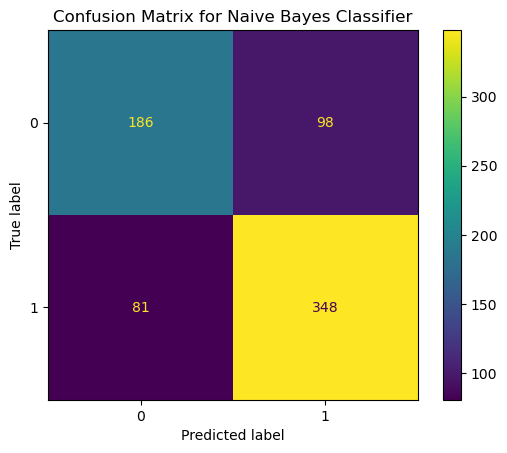

In [32]:
print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=["low risk", "high risk"]))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Naive Bayes Classifier')